In [10]:
# Step 1: Upload train.csv or zip file
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

uploaded = files.upload()  # Select train.csv or the downloaded zip file

# If a zip file was uploaded, extract it first
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        print(f"Extracting {filename}...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('.')

# Load the train dataset
if os.path.exists('train.csv'):
    df = pd.read_csv('train.csv')
    print("Loaded successfully!")
    print(df.head())
else:
    print("Error: 'train.csv' not found. Please make sure train.csv was in the uploaded files or zip.")

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques (2).zip
Extracting house-prices-advanced-regression-techniques (2).zip...
Loaded successfully!
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...      

In [11]:
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nDuplicates:", df.duplicated().sum())
df.describe()

Shape: (1460, 81)
Missing values:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

Duplicates: 0


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


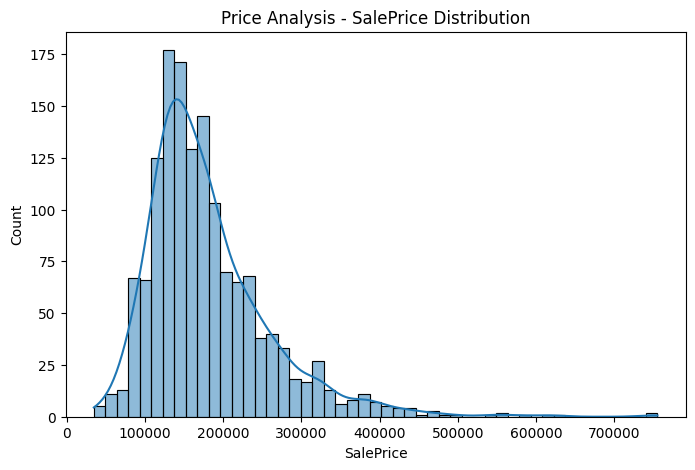

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Price Analysis - SalePrice Distribution')
plt.show()

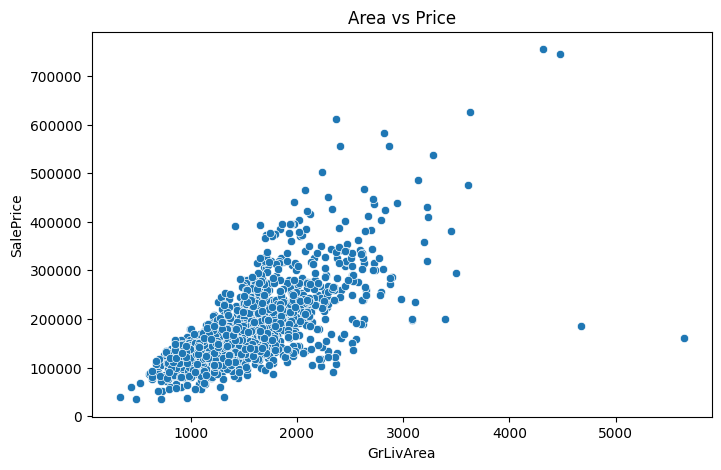

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('Area vs Price')
plt.show()

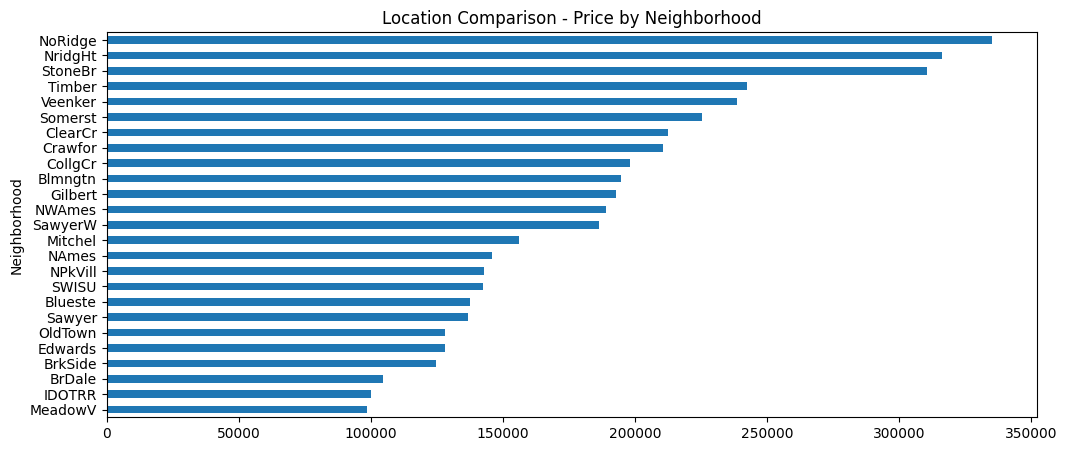

In [14]:
plt.figure(figsize=(12,5))
df.groupby('Neighborhood')['SalePrice'].mean().sort_values().plot(kind='barh')
plt.title('Location Comparison - Price by Neighborhood')
plt.show()

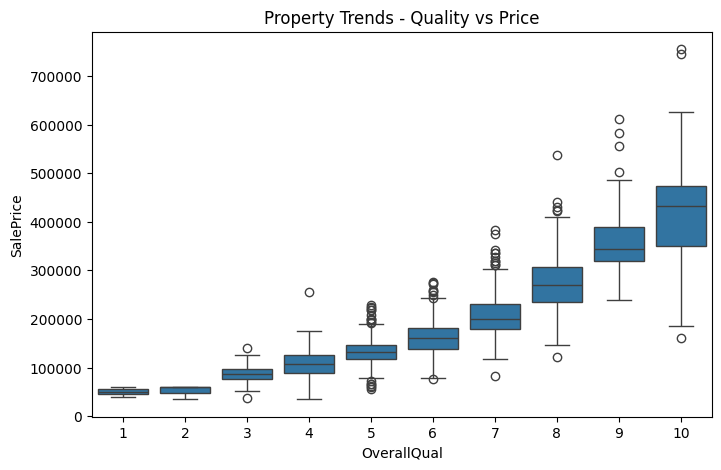

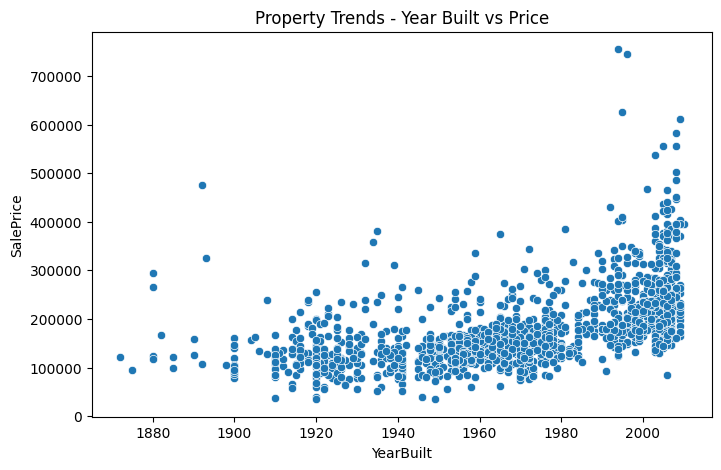

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('Property Trends - Quality vs Price')
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df)
plt.title('Property Trends - Year Built vs Price')
plt.show()

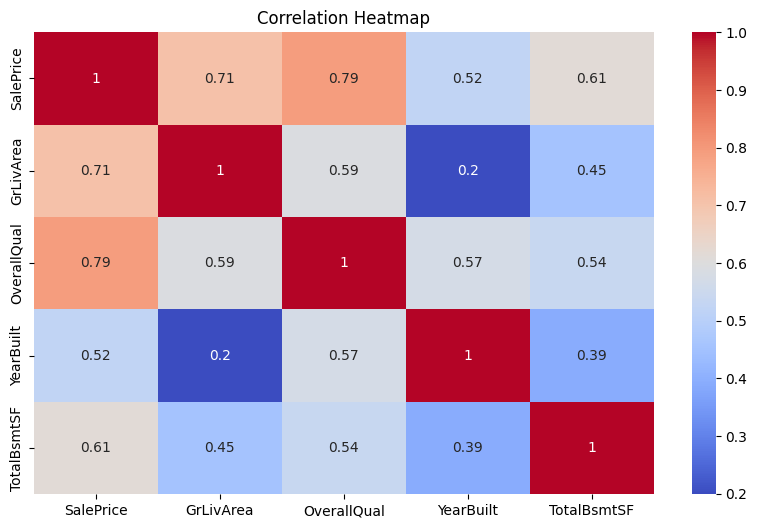

EDA DONE!


In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['SalePrice','GrLivArea','OverallQual','YearBuilt','TotalBsmtSF']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
print("EDA DONE!")


In [19]:
# I will teach computer to guess price
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. Take only 3 important columns
X = df[['GrLivArea','OverallQual','YearBuilt']]
y = df['SalePrice']

# 2. Fill empty values with 0
X = X.fillna(0)

# 3. Split for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Teach computer
model = RandomForestRegressor()
model.fit(X_train, y_train)

# 5. Check how good it is
score = model.score(X_test, y_test) * 100
print(f"Your model is {score:.2f}% accurate!")


Your model is 83.95% accurate!
